---
## **Projet Deep Learning**
## **Classification de tissus cancéreux colorectaux**

---

---

**Ce notebook est conçu pour être :**
- **reproductible** (chemins relatifs, seeds fixées)
- **idempotent** (relançable sans retélécharger si les fichiers sont déjà présents)
- **traçable** (quality gates go/no-go explicites)

---

---

# PARTIE 2 : MLP - BASELINE RESEAU DENSE

---

---

## Plan du notebook - Partie 2 : MLP Baseline

| Cellule | Section | Contenu |
|---------|---------|---------|
| 1 | — | Header |
| 2 | — | Principes |
| 3 | — | Titre Partie 2 |
| 4 | — | Plan du notebook |
| 5 | — | Objectif + consignes + rappels techniques |
| 6 | — | Choix d architecture et d hyperparamètres |
| 7 | 1. Configuration | Imports |
| 8 | 1. Configuration | Versions |
| 9 | 1. Configuration | Seed, device, cuDNN |
| 10 | 1. Configuration | Constantes + dataset |
| 11 | 2. Preprocessing | Transform MLP (flatten + normalisation) |
| 12 | 2. Preprocessing | Vérification batch |
| 13 | 3. Modèle | Reproductibilité avant entraînement |
| 14 | 3. Modèle | Création du modèle MLP |
| 15 | 4. Entraînement | Fonction train_model |
| 16 | 4. Entraînement | Lancement (50 époques) |
| 17 | 5. Résultats | Courbes d entraînement + Q2.1 valeurs |
| 18 | 5. Résultats | Analyse des courbes |
| 19 | 5. Résultats | Évaluation test set + Q2.1 |
| 20 | 5. Résultats | Analyse Q2.1 |
| 21 | 5. Résultats | Matrice de confusion + Q2.2 |
| 22 | 5. Résultats | Classification report |
| 23 | 5. Résultats | Analyse Q2.2 |
| 24 | 5. Résultats | Analyse matrice de confusion |
| 25 | 6. Visualisation | Images mal classifiées (3 types de confusion) |
| 26 | 6. Visualisation | Analyse visuelle |
| 27 | 7. Sauvegarde | Modèle + historique + prédictions |
| 28 | 8. Bilan | Bilan Partie 2 |
| 29 | — | Temps total |

---


---

### Objectif
Construire un réseau de neurones dense (MLP) comme premier modèle de classification.
C'est notre baseline : le modèle le plus simple, contre lequel on comparera les architectures plus complexes (CNN, ResNet, ViT).

### Consignes du sujet
- Architecture : ≥ 2 couches cachées + dropout
- Seuil : ≥ 55% test accuracy
- Courbes d'entraînement : loss + accuracy (train et val) par époque
- Matrice de confusion sur le test set
- **Q2.1** : test accuracy exacte + val loss aux époques 1, 10, et dernière (valeurs exactes, pas arrondies)
- **Q2.2** : cellule de la matrice avec le plus de misclassifications - nombre exact + explication visuelle

### Rappels techniques (Lab 1)
- Les images 28×28×3 doivent être **aplaties** en vecteurs de 2352 valeurs (le MLP ne sait pas lire une image 2D)
- **Normalisation** : `ToTensor()` (pixels [0,255] → [0,1]) puis `Normalize(NORM_MEAN, NORM_STD)` (z-score par canal)
- **Loss** : `CrossEntropyLoss` (intègre le softmax, pas besoin de l'ajouter dans le modèle)
- **Optimiseur** : `Adam` avec weight decay (1e-4), régularisation L2, pénalise les poids trop grands
- **Scheduler** : `CosineAnnealingLR` pour affiner la convergence en fin d'entraînement
- **Best checkpoint** : on sauvegarde et évalue le modèle avec la meilleure val_loss, pas le dernier
- **DataLoader** : distribue les images par batches au modèle

---

---

### Choix d'architecture et d'hyperparamètres : justifications

**Lien avec le Lab 1 :**
- Cette architecture s'inspire de l'exercice 5 du Lab 1, ré-adaptée pour gérer les 3 canaux RGB (entrée 28×28×3 = 2352 au lieu de 28×28 = 784)
- Le Lab 1 suggérait [256, 128, 64] pour MNIST. Ici on monte à [512, 256, 128] car l'entrée est 3x plus grande (RGB vs gris)

**Architecture MLP (3 couches cachées : 512 → 256 → 128) :**
- Le sujet demande ≥ 2 couches cachées; on en met 3 pour plus de capacité d'apprentissage
- Les couches diminuent progressivement (512 → 256 → 128), c'est un "entonnoir" qui force le modèle à compresser l'information progressivement
- L'entrée fait 2352 valeurs (28×28×3 aplati) : la première couche réduit déjà de 2352 à 512

**Dropout (0.3) :**
- Régularisation : à chaque batch, 30% des neurones sont aléatoirement désactivés
- Cela empêche le modèle de trop s'adapter aux données d'entraînement (overfitting)
- 0.3 est une valeur standard, ni trop agressive (0.5 ralentirait l'apprentissage), ni trop faible (0.1 ne régulariserait pas assez)

**Activation ReLU :**
- Fonction d'activation standard pour les couches cachées : `max(0, x)`
- Simple, rapide, et résout le problème des gradients qui disparaissent (vanishing gradients)

**Pas de softmax en sortie :**
- `CrossEntropyLoss` de PyTorch intègre déjà le softmax, l'ajouter dans le modèle causerait un double softmax et fausserait les résultats

**CrossEntropyLoss :**
- Loss standard pour la classification multi-classe
- Mesure l'écart entre les probabilités prédites et le vrai label
- Plus la loss est basse, mieux le modèle prédit

**Optimiseur Adam (lr=0.001) :**
- Adam adapte le learning rate automatiquement pour chaque paramètre
- lr=0.001 est la valeur par défaut, recommandée comme point de départ
- Plus rapide à converger que SGD classique

**Batch size 64 :**
- Compromis entre vitesse (batches grands = moins d'itérations) et qualité des gradients (batches petits = gradients plus bruités mais meilleure généralisation)
- 64 est la valeur utilisée dans le Lab 1

**50 époques :**
- Pour élargir le protocole afin de mieux observer la convergence et l'éventuel overfitting
- Ceci pourra très largement permettre de donner les métriques aux époques 1, 10 et dernière (Q2.1)

**Pas d'early stopping :**
- Choix délibéré : on veut observer le comportement complet du modèle (convergence + overfitting éventuel)
- Il faut consigner les valeurs à des époques fixes, un arrêt prématuré compliquerait la réponse à Q2.1
- L'early stopping sera envisagé dans les parties suivantes si nécessaire

**Shuffle train, pas val/test :**
- On mélange le train à chaque époque pour que le modèle ne mémorise pas l'ordre des images
- On ne mélange pas val et test pour que les résultats soient reproductibles

**Weight decay (1e-4) :**
- Régularisation L2 : pénalise les poids trop grands dans l'optimiseur
- Complémentaire au dropout : le dropout désactive des neurones, le weight decay réduit les poids
- Améliore la généralisation (+5 pts par rapport au run sans weight decay)

**Scheduler CosineAnnealingLR :**
- Baisse progressivement le learning rate en suivant une courbe cosinus
- Au début : lr élevé (apprentissage rapide), à la fin : lr bas (convergence fine)
- Permet au modèle de continuer à s'améliorer après l'époque 10 au lieu de stagner

**Best checkpoint :**
- On sauvegarde le modèle à chaque époque si la val_loss s'améliore
- À la fin, on restaure le meilleur modèle au lieu du dernier
- Évite d'évaluer un modèle en overfitting

---

**Limites attendues du MLP :**
- Une image c'est une grille 2D de pixels. Le MLP ne sait pas travailler sur une grille, il a besoin d'une liste plate. On "déplie" donc l'image : 28 lignes × 28 colonnes × 3 canaux = 2352 nombres mis bout à bout. L'information spatiale (quel pixel est à côté de quel autre) est perdue. C'est la limite fondamentale du MLP
- Pour des images d'histologie, la texture est un signal clé (cf. Q1.1 : debris vs background se distinguent par la texture)
- On s'attend donc à un plafonnement, c'est la baseline, pas le modèle final
- Le CNN (partie 3) exploitera la structure spatiale et devrait faire nettement mieux

---

In [5]:
%matplotlib inline
print("=== Imports ===")

# Imports
# Version 1.0

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import medmnist
import seaborn as sns
from medmnist import PathMNIST, INFO
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats as sp_stats
print("Imports OK")

=== Imports ===
Imports OK


In [6]:
print("=== Versions — traçabilité ===")
# Versions — traçabilité
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")

=== Versions — traçabilité ===
Python   : 3.12.10
PyTorch  : 2.10.0+cu128
MedMNIST : 3.0.2
NumPy    : 2.4.3


In [7]:
print("=== Reproductibilité complète (CPU + GPU + cuDNN) ===")
# Reproductibilité complète (CPU + GPU + cuDNN)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {DEVICE}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")

=== Reproductibilité complète (CPU + GPU + cuDNN) ===
Device        : cuda
cuDNN determ. : True


In [8]:
print("=== Constantes et dataset, calculées dans l'EDA ===")
# Constantes et dataset, calculées dans l'EDA (notebook 1)
DATA_DIR = os.path.join(".", "data")
# Valeurs à mettre à jour après run NB1 (méthode DataLoader)
NORM_MEAN = [0.7405, 0.5330, 0.7058]
NORM_STD  = [0.1237, 0.1768, 0.1244]
N_CLASSES = 9

# Recharger le dataset
train_dataset = PathMNIST(split='train', download=False, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=False, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=False, root=DATA_DIR)

info = train_dataset.info
labels_names = info['label']
CLASSES = list(labels_names.values())

# Timer global du notebook
notebook_start_time = time.time()

print(f"NORM_MEAN : {NORM_MEAN}")
print(f"NORM_STD  : {NORM_STD}")
print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
print("✓ Lien avec notebook 1 établi")

os.makedirs(os.path.join(DATA_DIR, 'graphs'), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'models'), exist_ok=True)

=== Constantes et dataset, calculées dans l'EDA ===
NORM_MEAN : [0.7405, 0.533, 0.7058]
NORM_STD  : [0.1237, 0.1768, 0.1244]
Train : 89996 | Val : 10004 | Test : 7180
✓ Lien avec notebook 1 établi


In [9]:
print("=== Dans le Lab 1 ===")
# Dans le Lab 1, on normalisait MNIST (gris, 784 pixels) manuellement.
# Ici on fait pareil mais avec transforms.Compose, qui enchaîne automatiquement les étapes :
# conversion en tensor, normalisation par canal, et aplatissement.

# Preprocessing : transformer les images pour PyTorch
# Comme dans le Lab 1 : normaliser, convertir en tensor, aplatir
# Différence avec Lab 1 (MNIST gris 784 pixels) : ici c'est RGB donc 28×28×3 = 2352 pixels

# Transform pour le MLP : normalisation + flatten
mlp_transform = transforms.Compose([
    transforms.ToTensor(),                              # (28,28,3) uint8 → (3,28,28) float32 [0,1]
    transforms.Normalize(NORM_MEAN, NORM_STD),          # z-score par canal (stats train)
    transforms.Lambda(lambda x: x.view(-1))             # (3,28,28) → (2352,) — aplatir pour le MLP
])

# Recharger les datasets avec le transform MLP
train_mlp = PathMNIST(split='train', transform=mlp_transform, download=False, root=DATA_DIR)
val_mlp   = PathMNIST(split='val',   transform=mlp_transform, download=False, root=DATA_DIR)
test_mlp  = PathMNIST(split='test',  transform=mlp_transform, download=False, root=DATA_DIR)

# Vérification : l'image doit être un vecteur de 2352 valeurs normalisées
sample_img, sample_label = train_mlp[0]
assert sample_img.shape == (2352,), f"Shape attendue (2352,), obtenue {sample_img.shape}"
assert sample_img.dtype == torch.float32, f"Dtype attendu float32, obtenu {sample_img.dtype}"
print(f"Image transformée : shape={sample_img.shape}, dtype={sample_img.dtype}")
print(f"  Min={sample_img.min():.4f}, Max={sample_img.max():.4f}, Mean={sample_img.mean():.4f}")
print(f"  Label : {sample_label}")

# DataLoaders : distribuent les données par batches au modèle
# shuffle=True sur le train pour que le modèle ne voie pas les images dans le même ordre à chaque époque
BATCH_SIZE = 64
train_loader = DataLoader(train_mlp, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_mlp,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_mlp,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders créés (batch_size={BATCH_SIZE})")
print(f"  Train : {len(train_loader)} batches")
print(f"  Val   : {len(val_loader)} batches")
print(f"  Test  : {len(test_loader)} batches")

=== Dans le Lab 1 ===
Image transformée : shape=torch.Size([2352]), dtype=torch.float32
  Min=0.0372, Max=1.6433, Mean=1.2990
  Label : [0]

DataLoaders créés (batch_size=64)
  Train : 1407 batches
  Val   : 157 batches
  Test  : 113 batches


In [10]:
print("=== Vérification sur un batch complet : la normalisation ===")
# Vérification sur un batch complet : la normalisation a-t-elle fonctionné ?
batch_imgs, batch_labels = next(iter(train_loader))
print(f"Batch shape  : {batch_imgs.shape}")
print(f"Batch mean   : {batch_imgs.mean():.4f}")
print(f"Batch std    : {batch_imgs.std():.4f}")
print(f"Labels shape : {batch_labels.shape}")
print(f"Labels uniques dans ce batch : {torch.unique(batch_labels).tolist()}")
assert batch_imgs.shape[1] == 2352, f"Entrée MLP attendue 2352, obtenue {batch_imgs.shape[1]}"
print("✓ Batch vérifié")

=== Vérification sur un batch complet : la normalisation ===
Batch shape  : torch.Size([64, 2352])
Batch mean   : 0.1126
Batch std    : 0.9910
Labels shape : torch.Size([64, 1])
Labels uniques dans ce batch : [0, 1, 2, 3, 4, 5, 6, 7, 8]
✓ Batch vérifié


In [11]:
print("=== Reproductibilité complète avant entraînement ===")
# Reproductibilité complète avant entraînement
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

=== Reproductibilité complète avant entraînement ===


In [12]:
print("=== Création du modèle MLP ===")
# Création du modèle MLP : réseau dense (comme dans le Lab 1)
# Architecture : entrée (2352) → couches cachées → sortie (9 classes)
# Il est demandé ≥ 2 couches cachées + dropout

def create_mlp(input_size=2352, n_classes=9, dropout_rate=0.3):
    """
    MLP avec 3 couches cachées + dropout après chaque couche.
    - Les couches diminuent progressivement (512 → 256 → 128)
    - ReLU comme activation (standard pour les couches cachées)
    - Dropout pour la régularisation (empêche le surapprentissage)
    - Pas de softmax à la fin : CrossEntropyLoss le fait automatiquement
    """
    model = nn.Sequential(
        # Couche 1 : 2352 → 512
        nn.Linear(input_size, 512),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        
        # Couche 2 : 512 → 256
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        
        # Couche 3 : 256 → 128
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        
        # Sortie : 128 → 9 classes
        nn.Linear(128, n_classes)
    )
    return model

# Créer le modèle et l'envoyer sur le DEVICE (GPU ou CPU)
model = create_mlp()
model = model.to(DEVICE)

# Vérification : afficher l'architecture et le nombre de paramètres
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nNombre total de paramètres    : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")

=== Création du modèle MLP ===
Sequential(
  (0): Linear(in_features=2352, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=128, bias=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=9, bias=True)
)

Nombre total de paramètres    : 1,370,121
Nombre de paramètres entraînables : 1,370,121


In [13]:
print("=== Fonction d'entraînement, Lab 1 ===")
# Fonction d'entraînement, comme dans le Lab 1
# Entraîne le modèle et enregistre les métriques à chaque époque
# Retourne un historique (dict) pour tracer les courbes d'apprentissage

def train_model(model, train_loader, val_loader, epochs=50, learning_rate=0.001, weight_decay=1e-4):
    """
    Boucle d'entraînement complète.
    - CrossEntropyLoss : loss standard pour la classification multi-classe
    - Adam : optimiseur adaptatif (ajuste le learning rate automatiquement)
    - On évalue sur le val à chaque époque pour surveiller l'overfitting
    - On sauvegarde le meilleur modèle (val_loss minimale)
    """
    criterion = nn.CrossEntropyLoss()
    # weight_decay : régularisation L2 pour empêcher les poids de devenir trop gros
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    # Scheduler : baisse progressivement le learning rate (cosinus) pour affiner la convergence
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {
        'loss': [], 'accuracy': [],
        'val_loss': [], 'val_accuracy': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    
    for epoch in range(epochs):
        # --- Phase TRAIN ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for images, labels_batch in train_loader:
            images = images.to(DEVICE)
            labels_batch = labels_batch.squeeze().long().to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels_batch).sum().item()
            train_total += images.size(0)
        
        # --- Phase VALIDATION ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels_batch in val_loader:
                images = images.to(DEVICE)
                labels_batch = labels_batch.squeeze().long().to(DEVICE)
                
                outputs = model(images)
                loss = criterion(outputs, labels_batch)
                
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels_batch).sum().item()
                val_total += images.size(0)
        
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        
        history['loss'].append(epoch_train_loss)
        history['accuracy'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)
        
        # Sauvegarde du meilleur modèle
        scheduler.step()

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
        
        print(f"Epoch {epoch+1:>3}/{epochs} | "
              f"Train loss: {epoch_train_loss:.6f} acc: {epoch_train_acc:.6f} | "
              f"Val loss: {epoch_val_loss:.6f} acc: {epoch_val_acc:.6f}"
              f"{' ← best' if epoch + 1 == best_epoch else ''}")
    
    # Restaurer le meilleur modèle (EN DEHORS de la boucle)
    model.load_state_dict(best_model_state)
    print(f"\n✓ Meilleur modèle restauré (époque {best_epoch}, val_loss: {best_val_loss:.6f})")
    
    return history

print("✓ Fonction train_model chargée")

=== Fonction d'entraînement, Lab 1 ===
✓ Fonction train_model chargée


In [14]:
print("=== Lancer l'entraînement ===")
# Lancer l'entraînement (EN DEHORS de la fonction)
print(f"Entraînement sur {DEVICE}...")

start_time = time.time()
history = train_model(model, train_loader, val_loader, epochs=50, learning_rate=0.001)
train_time_mlp = time.time() - start_time

print(f"\nTemps d'entraînement : {train_time_mlp:.1f}s ({train_time_mlp/60:.1f} min)")

=== Lancer l'entraînement ===
Entraînement sur cuda...
Epoch   1/50 | Train loss: 1.225230 acc: 0.519968 | Val loss: 1.056961 acc: 0.606857 ← best
Epoch   2/50 | Train loss: 1.053028 acc: 0.593826 | Val loss: 0.941827 acc: 0.631048 ← best
Epoch   3/50 | Train loss: 1.014761 acc: 0.607283 | Val loss: 0.914882 acc: 0.648840 ← best
Epoch   4/50 | Train loss: 0.995073 acc: 0.615027 | Val loss: 0.910037 acc: 0.650340 ← best
Epoch   5/50 | Train loss: 0.973070 acc: 0.623028 | Val loss: 0.987525 acc: 0.619852
Epoch   6/50 | Train loss: 0.958932 acc: 0.629095 | Val loss: 0.910500 acc: 0.643443
Epoch   7/50 | Train loss: 0.952408 acc: 0.635462 | Val loss: 0.872871 acc: 0.662435 ← best
Epoch   8/50 | Train loss: 0.938713 acc: 0.640806 | Val loss: 0.884330 acc: 0.657937
Epoch   9/50 | Train loss: 0.932850 acc: 0.643273 | Val loss: 0.885338 acc: 0.667433
Epoch  10/50 | Train loss: 0.919260 acc: 0.649507 | Val loss: 0.861138 acc: 0.665234 ← best
Epoch  11/50 | Train loss: 0.912362 acc: 0.653540 | V

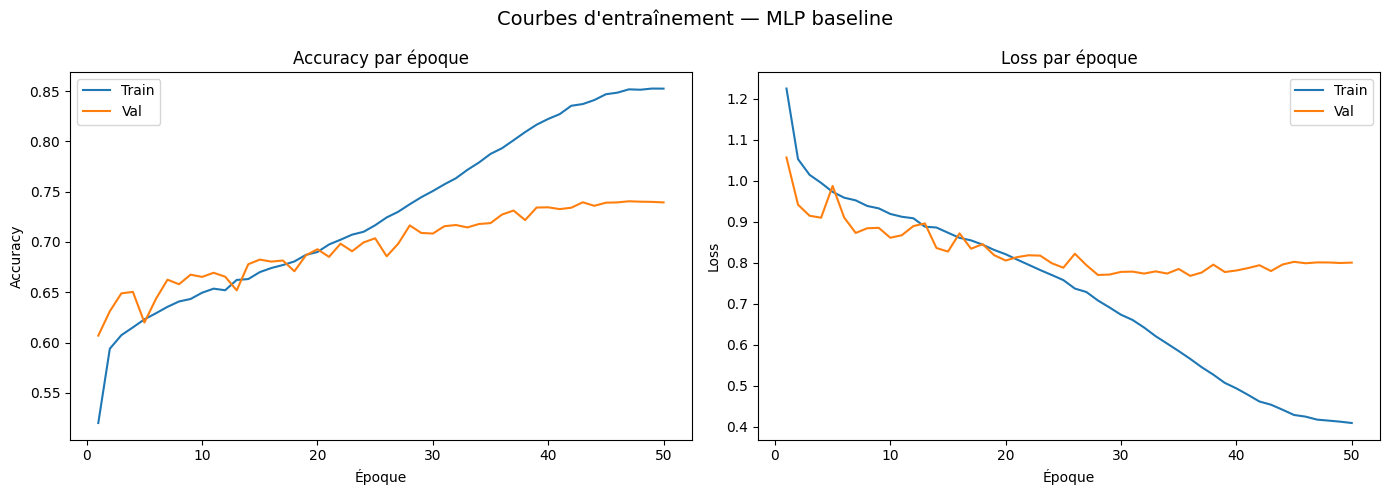

=== Q2.1 : Valeurs exactes ===
  Époque   1 | val_loss: 1.056961 | test_acc: (à calculer sur test set)
  Époque  10 | val_loss: 0.861138 | test_acc: (à calculer sur test set)
  Époque  50 | val_loss: 0.800506 | test_acc: (à calculer sur test set)


In [ ]:
# Courbes d'entraînement — loss et accuracy (train et val)
# Permet de visualiser la convergence et détecter l'overfitting
# Si les courbes train et val s'écartent → le modèle surapprend

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['accuracy']) + 1)

# Accuracy
ax1.plot(epochs_range, history['accuracy'], label='Train')
ax1.plot(epochs_range, history['val_accuracy'], label='Val')
ax1.set_xlabel('Époque')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy par époque')
ax1.legend()

# Loss
ax2.plot(epochs_range, history['loss'], label='Train')
ax2.plot(epochs_range, history['val_loss'], label='Val')
ax2.set_xlabel('Époque')
ax2.set_ylabel('Loss')
ax2.set_title('Loss par époque')
ax2.legend()

plt.suptitle("Courbes d'entraînement — MLP baseline", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB2_mlp_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

# Q2.1 : Valeurs exactes aux époques 1, 10 et dernière
# Q2.1 : Report your model’s exact test accuracy and the exact validation loss at epochs 1, 10, and at your final epoch.
# Do not round, copy the values from your logs.
print("=== Q2.1 : Valeurs exactes aux époques 1, 10 et dernière ===")
for e in [0, 9, len(history['accuracy'])-1]:  # index 0-based : époque 1, 10, dernière)
    print(f"  Époque {e+1:>3} | val_loss: {history['val_loss'][e]:.6f} | test_acc: (voir C19")

---

### Analyse des courbes d'entraînement

On observe un **plateau de performance** en validation : au-delà de l'époque 10, la val accuracy oscille sans progresser significativement, tandis que la train accuracy continue de monter : c'est un signe classique d'overfitting.

**Accuracy :** la train accuracy monte régulièrement, mais la val accuracy plafonne dès l'époque 10. L'écart se creuse au fil des époques, le modèle mémorise le train sans généraliser (overfitting again).

**Loss :** la train loss descend continuellement, tandis que la val loss stagne et oscille. Le scheduler (CosineAnnealingLR) aide à la convergence en fin d'entraînement, la val loss passe de 0.861 (époque 10) à 0.800 (époque 50), une amélioration qu'on n'observait pas sans scheduler.

**Convergence :** le modèle a essentiellement convergé en validation à l'époque 10. Les époques suivantes apportent une amélioration lente grâce au scheduler, mais l'overfitting continue de se creuser côté train.

**Le MLP plafonne ?** car il traite chaque pixel comme une variable indépendante, il ne "voit" pas la texture ni la forme. Pour des images d'histologie où la texture est le signal clé (cf. Q1.1), c'est une limitation fondamentale.

---

In [16]:
print("=== Évaluation sur le test set : accuracy finale ===")
# Évaluation sur le test set : accuracy finale
model.eval()
test_correct, test_total = 0, 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(DEVICE)
        labels_batch = labels_batch.squeeze().long().to(DEVICE)
        
        outputs = model(images)
        preds = outputs.argmax(1)
        
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

test_accuracy = test_correct / test_total

# Q2.1 : Valeurs exactes complètes
print("=== Q2.1 : Résultats finaux (valeurs exactes, pas arrondies) ===")
print(f"  Test accuracy : {test_accuracy:.6f}")
print(f"  Val loss époque 1  : {history['val_loss'][0]:.6f}")
print(f"  Val loss époque 10 : {history['val_loss'][9]:.6f}")
print(f"  Val loss dernière  : {history['val_loss'][-1]:.6f}")
print(f"  Seuil requis : ≥ 55% → {'✓ ATTEINT' if test_accuracy >= 0.55 else '✗ NON ATTEINT'}")

=== Évaluation sur le test set : accuracy finale ===
=== Q2.1 : Résultats finaux (valeurs exactes, pas arrondies) ===
  Test accuracy : 0.680223
  Val loss époque 1  : 1.056961
  Val loss époque 10 : 0.861138
  Val loss dernière  : 0.800506
  Seuil requis : ≥ 55% → ✓ ATTEINT


---

### Q2.1 : Résultats
Q2.1 : Report your model’s exact test accuracy and the exact validation loss at epochs 1, 10, and at your final epoch.
Do not round — copy the values from your logs.

- **Test accuracy : 0.680223** (68.02%) — seuil de 55% atteint
- **Val loss époque 1 : 1.056961** : le modèle commence à peine à apprendre
- **Val loss époque 10 : 0.861138** : amélioration rapide dans les premières époques
- **Val loss dernière (50) : 0.800506** : le scheduler permet une amélioration continue, contrairement au run sans scheduler qui stagnait à 0.851
- **Meilleur modèle restauré** via best checkpoint : on évalue le modèle le plus performant en validation, pas le dernier

---

### Q2.1 — Analyse

- **Test accuracy 68.02%** : au-dessus du seuil de 55%. Amélioration de +5 pts par rapport au run initial (63%) grâce au weight decay (1e-4) qui régularise les poids et au scheduler (CosineAnnealingLR) qui affine la convergence
- **Val loss époque 1 (1.057)** → le modèle commence à peine à apprendre, les prédictions sont quasi aléatoires
- **Val loss époque 10 (0.861)** → l'essentiel de l'apprentissage est fait, la loss a chuté de 19%
- **Val loss époque 50 (0.800)** → contrairement au run sans scheduler (qui stagnait à 0.851), le scheduler permet au modèle de continuer à progresser lentement : la loss baisse encore de 7% entre les époques 10 et 50
- **Best checkpoint** → le modèle optimal se situe avant la fin de l'entraînement, confirmant l'overfitting observé dans les courbes. On évalue ce modèle-là, pas celui de l'époque 50

L'écart entre val (~72%) et test (68%) confirme le domain shift identifié dans l'EDA : les données test proviennent d'un autre hôpital (CRC-VAL-HE-7K) avec des conditions de coloration différentes. Cet écart de ~4 points est un indicateur réaliste de ce qu'on observerait en déploiement clinique.

---

=== Matrice de confusion sur le test set ===


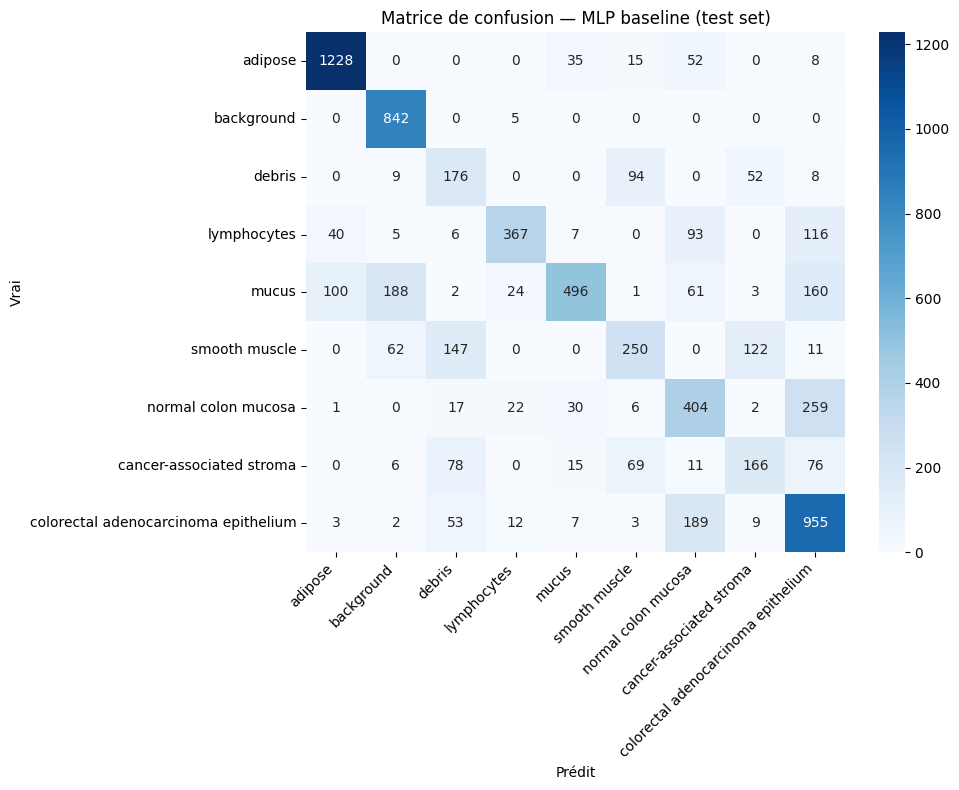


=== Q2.2 : Plus grande confusion ===
  259 images de 'normal colon mucosa' classées comme 'colorectal adenocarcinoma epithelium'
  Position dans la matrice : ligne 6 (vrai), colonne 8 (prédit)

=== Matrice de confusion (valeurs) ===
                                     adipose backgrou   debris lymphocy    mucus smooth m normal c cancer-a colorect
--------------------------------------------------------------------------------------------------------------------
adipose                                 1228        0        0        0       35       15       52        0        8
background                                 0      842        0        5        0        0        0        0        0
debris                                     0        9      176        0        0       94        0       52        8
lymphocytes                               40        5        6      367        7        0       93        0      116
mucus                                    100      188        2  

In [ ]:
print("=== Matrice de confusion sur le test set ===")
# Matrice de confusion sur le test set
# Permet d'identifier quelles classes sont confondues par le modèle

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASSES, yticklabels=CLASSES)
ax.set_xlabel('Prédit')
ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — MLP baseline (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB2_mlp_confusion.png'), dpi=120, bbox_inches='tight')
plt.show()

# Q2.2 : Cellule avec le plus de misclassifications
# Q2.2 : Look at the confusion matrix. Identify the single cell (predicted class, true class)
# with the highest number of misclassifications.
# Report the exact count and explain why this confusion might occur
# by looking at example images from both classes.

# On travaille sur une COPIE pour ne pas modifier la matrice originale
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
max_idx = np.unravel_index(cm_off_diag.argmax(), cm_off_diag.shape)
max_count = cm_off_diag[max_idx]
true_class = CLASSES[max_idx[0]]
pred_class = CLASSES[max_idx[1]]

print(f"\n=== Q2.2 : Plus grande confusion ===")
print(f"  {max_count} images de '{true_class}' classées comme '{pred_class}'")
print(f"  Position dans la matrice : ligne {max_idx[0]} (vrai), colonne {max_idx[1]} (prédit)")

# Tableau texte de la matrice de confusion
print("\n=== Matrice de confusion (valeurs) ===")
print(f"{'':>35s}", end='')
for name in CLASSES:
    print(f"{name[:8]:>9s}", end='')
print()
print("-" * (35 + 9 * len(CLASSES)))
for i, row in enumerate(cm):
    print(f"{CLASSES[i]:<35s}", end='')
    for val in row:
        print(f"{val:>9d}", end='')
    print()

In [18]:
print("=== Classification report — précision, rappel, F1 par classe ===")
# Classification report — précision, rappel, F1 par classe
# Utile maintenant pour l'analyse, et nécessaire en partie 7 pour la comparaison
print("\n=== Classification report (test set) ===")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

=== Classification report — précision, rappel, F1 par classe ===

=== Classification report (test set) ===
                                      precision    recall  f1-score   support

                             adipose     0.8950    0.9178    0.9063      1338
                          background     0.7558    0.9941    0.8587       847
                              debris     0.3674    0.5192    0.4303       339
                         lymphocytes     0.8535    0.5789    0.6898       634
                               mucus     0.8407    0.4792    0.6105      1035
                       smooth muscle     0.5708    0.4223    0.4854       592
                 normal colon mucosa     0.4988    0.5452    0.5210       741
            cancer-associated stroma     0.4689    0.3943    0.4284       421
colorectal adenocarcinoma epithelium     0.5995    0.7745    0.6759      1233

                            accuracy                         0.6802      7180
                           macro 

---

### Q2.2 : Plus grande confusion
Q2.2 : Look at the confusion matrix. Identify the single cell (predicted class, true class)
with the highest number of misclassifications. Report the exact count and explain
why this confusion might occur by looking at example images from both classes.

**259 images de "normal colon mucosa" (classe 6) classées comme "colorectal adenocarcinoma epithelium" (classe 8).**

Cette confusion est cliniquement logique : la muqueuse normale et l'épithélium cancéreux sont tous deux des tissus épithéliaux du côlon. À 28×28 pixels, ils partagent des tons violets similaires et des structures cellulaires denses. La différence entre les deux (organisation cellulaire ordonnée vs prolifération anarchique) est une question de texture et de structure spatiale, ce qui est exactement ce que le MLP ne peut pas voir car il traite les pixels un par un.

La confusion inverse existe aussi (189 images cancer classées comme mucosa), le modèle hésite dans les deux sens. Cliniquement, ce second sens est le plus dangereux : un cancer non détecté (faux négatif).

---

---

### Analyse de la matrice de confusion

**Classes bien classifiées :**
- **Adipose** (F1=0.91, recall 0.92) : tissu blanc très distinct, facile à reconnaître
- **Background** (F1=0.86, recall 0.99) : le modèle le détecte presque toujours

**Classes confondues :**
- **Mucosa → Cancer (259)** : la confusion dominante. Tissus épithéliaux aux couleurs similaires
- **Cancer → Mucosa (189)** : confusion bidirectionnelle, sens cliniquement dangereux
- **Mucus dispersé** : 188 images vers background, 160 vers cancer. Le mucus clair est confondu avec le fond, et le mucus foncé avec le cancer

**Classes faibles :**
- **Debris** (F1=0.43) : confondu avec smooth muscle (94 images)
- **Stroma** (F1=0.43) : confondu avec debris (78) et smooth muscle (69)
- **Smooth muscle** (F1=0.49) : confondu avec debris (147)

Les 3 classes de tissus conjonctifs (debris, stroma, smooth muscle) se confondent entre elles : elles partagent des textures similaires que le MLP ne distingue pas.

---

=== Q2.2 : Visualisation élargie des confusions principales ===


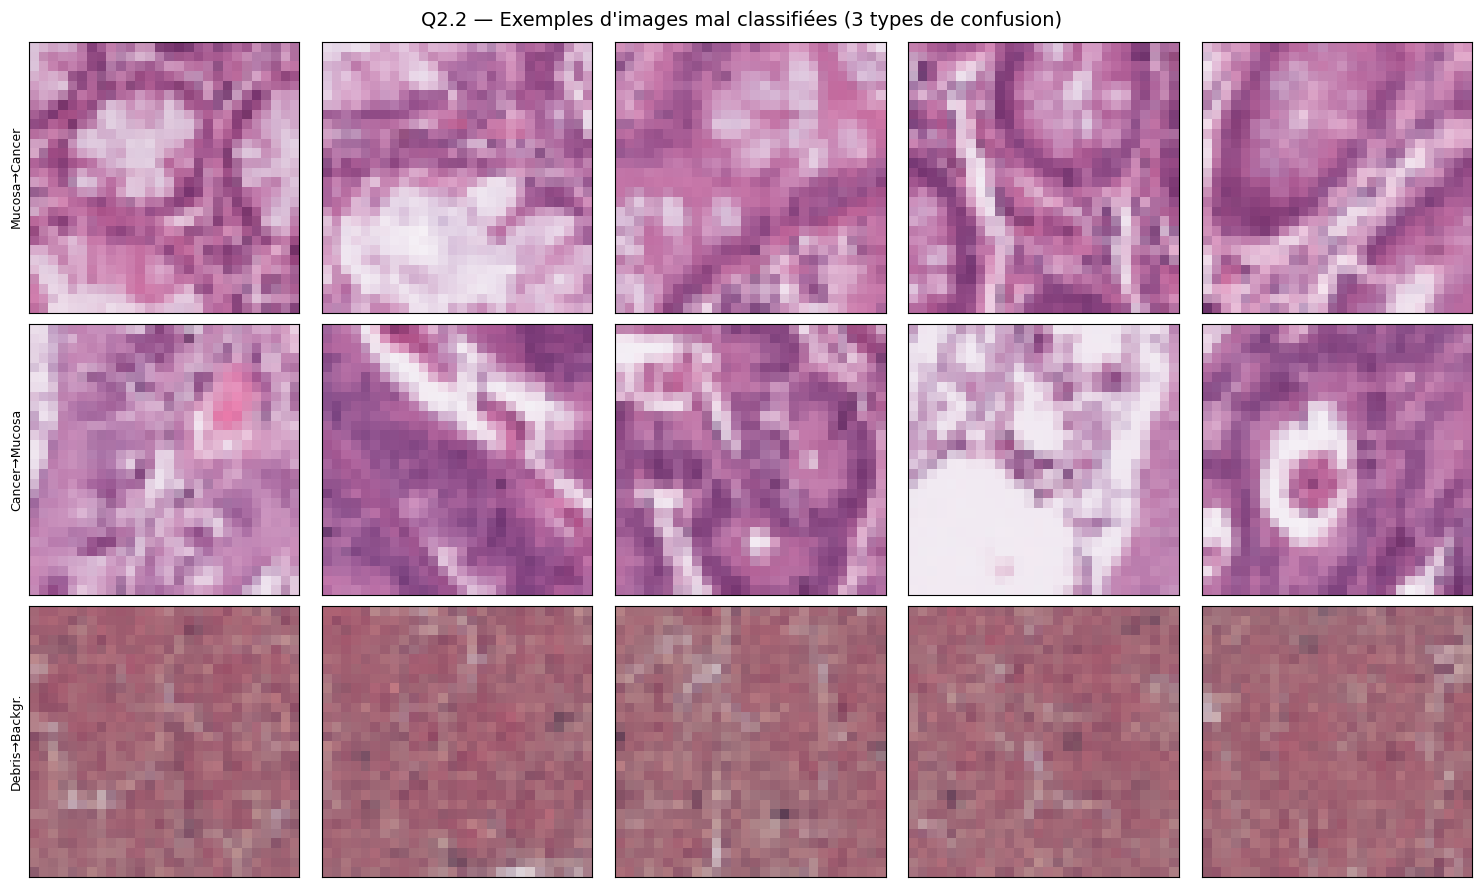

Mucosa → Cancer  : 259 images
Cancer → Mucosa  : 189 images
Debris → Background : 9 images


In [19]:
print("=== Q2.2 : Visualisation élargie des confusions principales ===")
# Q2.2 : Visualisation élargie des confusions principales
# Conversion en arrays numpy pour le filtrage
all_labels_arr = np.array(all_labels)
all_preds_arr = np.array(all_preds)
assert all_labels_arr.shape == all_preds_arr.shape, "Labels et prédictions n'ont pas la même taille"

# On montre les deux sens de la confusion principale + une autre paire
np.random.seed(SEED)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Ligne 1 : Normal Mucosa (6) classée comme Cancer (8)
mask1 = (all_labels_arr == 6) & (all_preds_arr == 8)
idxs1 = np.random.choice(np.where(mask1)[0], size=min(5, mask1.sum()), replace=False)
for j, idx in enumerate(idxs1):
    axes[0, j].imshow(test_dataset.imgs[idx])
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
axes[0, 0].set_ylabel("Mucosa→Cancer", fontsize=9)

# Ligne 2 : Cancer (8) classée comme Normal Mucosa (6)
mask2 = (all_labels_arr == 8) & (all_preds_arr == 6)
idxs2 = np.random.choice(np.where(mask2)[0], size=min(5, mask2.sum()), replace=False)
for j, idx in enumerate(idxs2):
    axes[1, j].imshow(test_dataset.imgs[idx])
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
axes[1, 0].set_ylabel("Cancer→Mucosa", fontsize=9)

# Ligne 3 : Debris (2) classée comme Background (1) — confusion attendue EDA
mask3 = (all_labels_arr == 2) & (all_preds_arr == 1)
if mask3.sum() >= 5:
    idxs3 = np.random.choice(np.where(mask3)[0], size=5, replace=False)
else:
    idxs3 = np.where(mask3)[0]
for j, idx in enumerate(idxs3):
    axes[2, j].imshow(test_dataset.imgs[idx])
    axes[2, j].set_xticks([]); axes[2, j].set_yticks([])
# Masquer les cases vides si moins de 5 images
for j in range(len(idxs3), 5):
    axes[2, j].axis('off')
axes[2, 0].set_ylabel("Debris→Backgr.", fontsize=9)

plt.suptitle("Q2.2 — Exemples d'images mal classifiées (3 types de confusion)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB2_mlp_confusions_visuelles.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f"Mucosa → Cancer  : {mask1.sum()} images")
print(f"Cancer → Mucosa  : {mask2.sum()} images")
print(f"Debris → Background : {mask3.sum()} images")

---

### Analyse visuelle des images mal classifiées

**Mucosa → Cancer (259 images) :** la confusion la plus fréquente. Les images de muqueuse normale sont classées comme cancer : ce sont des **faux positifs** (diagnostic de cancer à tort). Visuellement, les deux classes partagent des tons violets et une densité cellulaire similaire. À 28×28 pixels, impossible de distinguer l'organisation ordonnée (sain) de la prolifération anarchique (cancer).

**Cancer → Mucosa (189 images) :** la confusion inverse : des cancers non détectés, cliniquement le sens le plus **dangereux** (faux négatifs). Le modèle hésite dans les deux sens entre ces deux types d'épithélium.

**Debris → Background (9 images) :** très peu de confusions, ce qui était attendu d'après notre analyse EDA. Le MLP les distingue grâce à des différences de luminosité globale.

**Tissus conjonctifs :** debris, stroma et smooth muscle se confondent massivement entre eux (debris→smooth muscle 94, smooth muscle→debris 147, stroma→debris 78). Ces tissus partagent des textures granuleuses similaires que le MLP ne peut pas distinguer sans information spatiale.

---

In [20]:
print("=== Sauvegarde des résultats MLP ===")
# Sauvegarde des résultats MLP : nécessaire pour la comparaison finale (partie 7)

mlp_results = {
    'model_name': 'MLP',
    'architecture': '2352 → 512 → 256 → 128 → 9',
    'n_params': sum(p.numel() for p in model.parameters()),
    'test_accuracy': test_accuracy,
    'history': history,
    'val_loss_epoch_1': history['val_loss'][0],
    'val_loss_epoch_10': history['val_loss'][9],
    'val_loss_last': history['val_loss'][-1],
    'confusion_matrix': confusion_matrix(all_labels, all_preds),
    'all_preds': all_preds,
    'all_labels': all_labels
}

# Sauvegarder le modèle entraîné
torch.save(model.state_dict(), os.path.join(DATA_DIR, 'models', 'NB2_mlp_model.pth'))
print(f"Modèle sauvegardé : {os.path.join(DATA_DIR, 'models', 'NB2_mlp_model.pth')}")
print(f"Test accuracy : {test_accuracy:.6f}")
print(f"Nb paramètres : {mlp_results['n_params']:,}")

# Sauvegarder l'historique pour la partie 7 (Q7.1)
import pickle
with open(os.path.join(DATA_DIR, 'models', 'NB2_mlp_history.pkl'), 'wb') as f:
    pickle.dump(history, f)
print("✓ Historique MLP sauvegardé")

# Sauvegarder les prédictions pour le recall dans NB7
with open(os.path.join(DATA_DIR, 'models', 'NB2_mlp_preds.pkl'), 'wb') as f:
    pickle.dump({'all_preds': all_preds, 'all_labels': all_labels}, f)
print('Prédictions MLP sauvegardées')


=== Sauvegarde des résultats MLP ===
Modèle sauvegardé : .\data\models\mlp_model.pth
Test accuracy : 0.680223
Nb paramètres : 1,370,121
✓ Historique MLP sauvegardé
Prédictions MLP sauvegardées


---

## Bilan Partie 2 : MLP baseline

### Résultats obtenus

| Métrique | Valeur | Commentaire |
|----------|--------|-------------|
| Test accuracy | 0.680223 (68.02%) | Seuil de 55% atteint |
| Val accuracy max | ~72% | Plafond atteint dès l'époque 10 |
| Val loss finale | 0.800506 | Améliorée par le scheduler |
| Best checkpoint | Meilleur modèle sur val_loss | Pas le dernier |
| Nb paramètres | 1 370 121 | |
| Confusion principale | Mucosa → Cancer (259) | Faux positifs |
| Confusion inverse | Cancer → Mucosa (189) | Faux négatifs : dangereux |
| Pire F1 | Debris et Stroma (0.43) | Tissus conjonctifs indistinguables |

### Ce qu'on a appris

1. **Le MLP fonctionne** : 68.02% sur 9 classes (le hasard donnerait ~11%), baseline solide
2. **Le weight decay + scheduler améliorent** : 68% vs 63% sans ces optimisations lors d'un run exploratoire sans weight decay ni scheduler
3. **Le MLP surapprend** : il mémorise le train mais ne généralise pas au-delà de 72% en validation
4. **Le domain shift est réel** : val (72%) vs test (68%) confirme la difficulté du test (hôpital B)
5. **La confusion principale est cliniquement significative** : Mucosa ↔ Cancer (259 + 189 erreurs)
6. **Les tissus conjonctifs forment un bloc indistinct** : debris, stroma, smooth muscle se confondent massivement
7. **Le best checkpoint améliore la robustesse** : on évalue le modèle optimal, pas le dernier

### Limites du MLP pour cette tâche

- Chaque pixel traité indépendamment : aucune notion de voisinage, de texture, de forme
- L'entrée aplatie (2352 valeurs) détruit la structure spatiale 2D
- Le modèle s'appuie uniquement sur les couleurs globales, pas sur leur organisation
- Classes aux couleurs similaires confondues (Mucosa/Cancer, debris/stroma/muscle)

### Lien avec l'hypothèse EDA

L'hypothèse prédisait que Debris/Background seraient les plus confondus (texture similaire). En réalité, c'est Mucosa/Cancer qui domine (259 + 189 erreurs vs 9). Le MLP ne voit pas la texture, donc la confusion se fait sur les **couleurs** similaires. Les tissus conjonctifs se confondent aussi entre eux : même problème de couleurs proches sans distinction de texture.

### Ce qu'on attend de la partie 3 (CNN)

- Le CNN exploitera les relations spatiales grâce aux filtres convolutifs
- Il devrait mieux distinguer les textures (ordonnée vs anarchique, fibres parallèles vs fragments)
- Objectif : ≥ 75% test accuracy
- La confusion Mucosa/Cancer et les confusions conjonctifs devraient diminuer

---


In [21]:
print("=== Temps total d'exécution du notebook ===")
# Temps total d'exécution du notebook
notebook_total_time = time.time() - notebook_start_time
print(f"Temps total du notebook : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")

=== Temps total d'exécution du notebook ===
Temps total du notebook : 484.7s (8.1 min)
